In [ ]:
# import dill
# with open("empirical_results/lcbench_known_cost_metrics_per_acq_updated.pkl", "rb") as f:
#     metrics_per_acq = dill.load(f)

In [ ]:
# import wandb
# from tqdm import tqdm
# import numpy as np

# api = wandb.Api()

# def load_lcbench_varying_cost_runs(data, acq):
#     runs = api.runs(path="ziv-scully-group/StoppingBayesOptEmpirical", filters={
#         "sweep": "qorb5uj0",
#         "config.dataset_name": data,
#         "config.acquisition_function": acq},
#         )
    
#     configs_and_metrics = []
#     for run in tqdm(runs):
#         metric_keys = ["config id", "estimated cumulative cost", "current best id", "current best observed"]
#         history = list(run.scan_history(keys = metric_keys, page_size=1_000_000_000))
#         metrics = {k: [d[k] for d in history] for k in metric_keys}
#         configs_and_metrics.append((run.config, metrics))

#     return configs_and_metrics

In [ ]:
# dataset_names = ['Fashion-MNIST', 'adult', 'higgs', 'volkert']
# acquisition_functions = ["PBGI-D"]

In [ ]:
# grouped_runs = {(d, a): load_lcbench_varying_cost_runs(d, a) for d in dataset_names for a in acquisition_functions}

100%|██████████| 50/50 [00:23<00:00,  2.13it/s]


In [ ]:
# import numpy as np

# for d in dataset_names:
#     for a in acquisition_functions:
#         if d not in metrics_per_acq:
#             metrics_per_acq[d] = {}
#         if a not in metrics_per_acq[d]:
#             metrics_per_acq[d][a] = {}

#         config_and_metrics_per_seed = grouped_runs[(d, a)]

#         # Extract metrics along with the seeds for sorting
#         seeds_and_metrics = [
#             (
#                 config['seed'],
#                 m['estimated cumulative cost'],
#                 m['config id'],
#                 m['current best id'],
#                 m['current best observed'],
#             )
#             for config, m in config_and_metrics_per_seed
#             if len(m['current best observed']) > 0
#         ]

#         # Sort by seed
#         seeds_and_metrics.sort(key=lambda x: x[0])

#         # Extract sorted metrics
#         metric_keys = [
#             "estimated cumulative cost",
#             "config id",
#             "current best id",
#             "current best observed",
#         ]

#         arrays = [
#             np.array([item[i + 1] for item in seeds_and_metrics], dtype=int if "id" in key else float)
#             for i, key in enumerate(metric_keys)
#         ]

#         print(d, a, arrays[1].shape)  # config_id is arrays[1]

#         for key, array in zip(metric_keys, arrays):
#             metrics_per_acq[d][a][key] = array

Fashion-MNIST PBGI-D (50, 201)
adult PBGI-D (50, 201)
higgs PBGI-D (50, 201)
volkert PBGI-D (50, 201)


In [ ]:
# import os
# import importlib.util

# root_dir = os.path.abspath("..")
# api_path = os.path.join(root_dir, "LCBench", "api.py")
# spec = importlib.util.spec_from_file_location("LCBench.api", api_path)
# api = importlib.util.module_from_spec(spec)
# spec.loader.exec_module(api)

# Benchmark = api.Benchmark

In [ ]:
# os.makedirs("../LCBench/cached", exist_ok=True)
# bench_dir = "../LCBench/cached/six_datasets_lw.json"
# bench = Benchmark(bench_dir, cache=False)

==> Loading data...
==> No cached data found or cache set to False.
==> Reading json data...
==> Done.


In [ ]:
# import numpy as np

# # Loop over each dataset and acquisition function.
# for d in dataset_names:
#     for a in acquisition_functions:
#         # Access current best IDs from the unified structure
#         best_ids = metrics_per_acq[d][a]["current best id"]
#         n_seeds, n_iterations = best_ids.shape
        
#         # Prepare arrays to store the test metrics
#         test_error_mat = np.empty((n_seeds, n_iterations))
        
#         # Use the best configuration IDs to query test metrics
#         for s in range(n_seeds):
#             for i in range(n_iterations):
#                 config_id = best_ids[s, i]
#                 test_error_mat[s, i] = 100-bench.query(d, "final_test_accuracy", config_id)
        
#         # Store in unified structure
#         metrics_per_acq[d][a]["final test error"] = test_error_mat

In [ ]:
# import dill

# with open("empirical_results/lcbench_known_cost_metrics_per_acq_with_PBGI_D.pkl", "wb") as f:
#     dill.dump(metrics_per_acq, f)

In [25]:
import dill
with open("empirical_results/lcbench_known_cost_metrics_per_acq_with_PBGI_D.pkl", "rb") as f:
    metrics_per_acq = dill.load(f)

In [26]:
# Import required libraries
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.interpolate import interp1d
from math import ceil

# Set up plotting style (following AutoML_Plotting.ipynb)
sns.set_style('whitegrid', {
    'grid.linestyle': '--',
    'grid.alpha': 0.4
})

plt.style.use('seaborn-v0_8-bright')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams.update({
    'font.size': 48,
    'axes.titlesize': 54,
    'axes.labelsize': 48,
    'legend.fontsize': 32,
    'xtick.labelsize': 40,
    'ytick.labelsize': 40,
    'figure.autolayout': False,
})

# Configuration
datasets = ['Fashion-MNIST', 'adult', 'higgs', 'volkert']
acquisition_functions = ['LogEIPC', 'PBGI(1e-3)', 'PBGI(1e-4)', 'PBGI(1e-5)', 'LCB', 'TS', 'PBGI-D']
init = 20

# Best accuracy per dataset
best_acc_per_dataset = {
    'Fashion-MNIST': 90.17316017316017,
    'adult': 83.00552211950115,
    'higgs': 71.86302385956238,
    'volkert': 62.765681026866915
}

cost_limit_per_dataset = {
    "Fashion-MNIST": 10000,
    "adult":         10000,
    "higgs":         10000,
    "volkert":       10000
}

# Colors for acquisition functions (colorblind-friendly)
acq_colors = {
    'LogEIPC': 'tab:blue',
    'PBGI(1e-3)': 'tab:olive',
    'PBGI(1e-4)': 'tab:orange', 
    'PBGI(1e-5)': 'tab:pink',
    'LCB': 'tab:purple',
    'TS': 'tab:brown',
    'PBGI-D': 'tab:red'
}

def style_spines(ax, color='black', linewidth=1):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_edgecolor(color)
        spine.set_linewidth(linewidth)


Creating comparison plot for first three datasets...


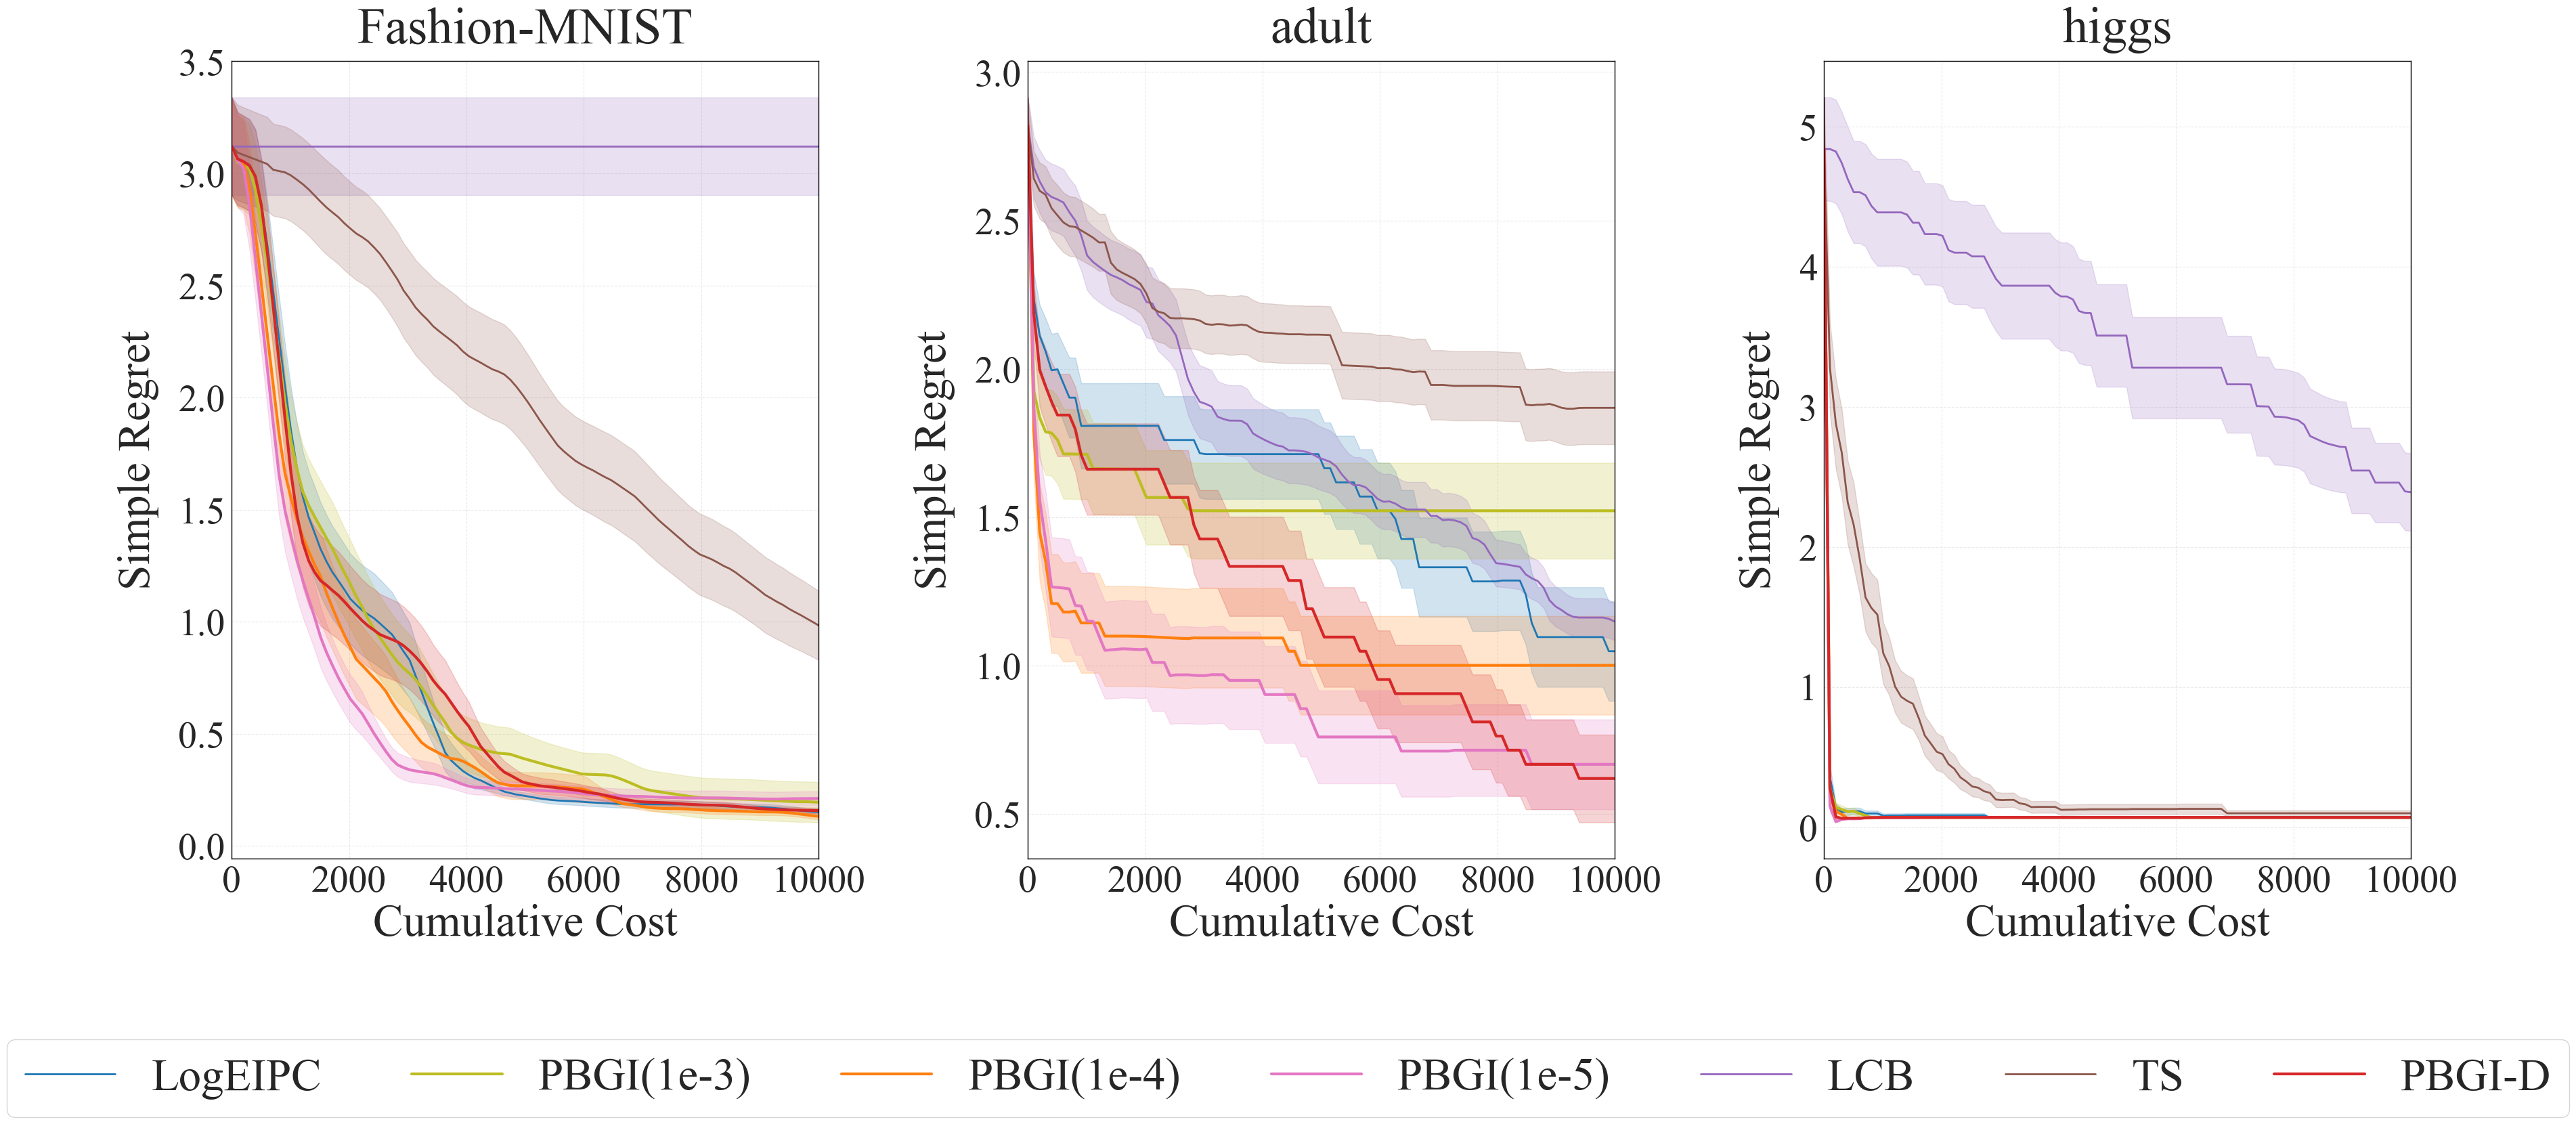

In [29]:
# Create a single figure with the first three datasets in a row
def create_three_dataset_comparison():
    # Create figure with 1x3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(36, 18))
    
    # First three datasets
    first_three_datasets = datasets[:3]
    
    for idx, dataset in enumerate(first_three_datasets):
        ax = axes[idx]
        best_acc = best_acc_per_dataset[dataset]
        best_error = 100. - best_acc
        cost_limit = cost_limit_per_dataset[dataset]
        
        # Create common cost grid for interpolation
        cost_grid = np.linspace(0, cost_limit, 100)
        
        for acq in acquisition_functions:
            if acq not in metrics_per_acq[dataset]:
                print(f"Warning: {acq} not found for dataset {dataset}")
                continue
                
            # Collect regret curves and cumulative costs for all seeds
            all_regret_at_costs = []
            
            for seed in range(len(metrics_per_acq[dataset][acq]["final test error"])):
                errs = metrics_per_acq[dataset][acq]["final test error"][seed]
                costs = metrics_per_acq[dataset][acq]["estimated cumulative cost"][seed]
                regrets = np.array(errs) - best_error
                
                # Remove any NaN values and ensure costs are sorted
                valid_mask = ~(np.isnan(errs) | np.isnan(costs))
                costs_clean = np.array(costs)[valid_mask]
                regrets_clean = regrets[valid_mask]
                
                if len(costs_clean) > 1:
                    # Sort by costs to ensure monotonic interpolation
                    sort_idx = np.argsort(costs_clean)
                    costs_sorted = costs_clean[sort_idx]
                    regrets_sorted = regrets_clean[sort_idx]
                    
                    # Interpolate regret at common cost points
                    try:
                        f_interp = interp1d(costs_sorted, regrets_sorted, 
                                           kind='linear', bounds_error=False, 
                                           fill_value=(regrets_sorted[0], regrets_sorted[-1]))
                        regrets_interp = f_interp(cost_grid)
                        all_regret_at_costs.append(regrets_interp)
                    except:
                        # Fallback if interpolation fails
                        continue
            
            if len(all_regret_at_costs) > 0:
                # Convert to numpy array for easier computation
                all_regret_at_costs = np.array(all_regret_at_costs)
                
                # Compute mean and std across seeds for each cost point
                mean_regret = np.mean(all_regret_at_costs, axis=0)
                std_regret = np.std(all_regret_at_costs, axis=0) / np.sqrt(all_regret_at_costs.shape[0])
                
                # Set line width - make PBGI-D bold
                linewidth = 3 if acq in ['PBGI-D', 'PBGI(1e-3)', 'PBGI(1e-4)', 'PBGI(1e-5)'] else 2
                
                # Plot regret curve vs cumulative costs with error bars
                ax.plot(cost_grid, mean_regret, 
                        color=acq_colors[acq], linewidth=linewidth, label=acq)
                ax.fill_between(cost_grid, 
                                mean_regret - std_regret, 
                                mean_regret + std_regret,
                                color=acq_colors[acq], alpha=0.2)
        
        # Set plot properties
        ax.set_xlim(0, cost_limit)
        ax.set_title(f'{dataset}', pad=20)  # Add padding to subplot title
        ax.set_xlabel('Cumulative Cost')
        ax.set_ylabel('Simple Regret', labelpad=20)  # Add padding to y-axis label
        ax.grid(True, linestyle='--', alpha=0.4)
        style_spines(ax)
        
        # Add some margin to the left side to give more space for y-axis label
        ax.margins(x=0.02, y=0.05)
        
        # Collect legend handles and labels from all subplots
        if idx == 0:
            handles, labels = ax.get_legend_handles_labels()
    
    # Create combined legend below the plot (larger with better spacing)
    fig.legend(handles, labels,
               loc='lower center',
               bbox_to_anchor=(0.5, -0.12),
               ncol=len(handles),
               fontsize=48)
    
    plt.tight_layout(rect=[0, 0.0, 1, 0.85])
    plt.savefig(f'../plots/BarPlot_budgeted.pdf', bbox_inches='tight')
    plt.show()
    
    return fig, axes

# Generate the three-dataset comparison plot
print("Creating comparison plot for first three datasets...")
fig, axes = create_three_dataset_comparison()
